In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [3]:
df["oni_lag1"] = df["oni"].shift(1)

display(
    df[
        ["date", "food_inflation", "oni", "oni_lag1"]
    ].head(15)
)

,date,food_inflation,oni,oni_lag1
0,2012-01-01,-0.210000,-0.72,NaN
1,2012-02-01,4.450000,-0.57,-0.72
2,2012-03-01,7.090000,-0.46,-0.57
3,2012-04-01,9.320000,-0.36,-0.46
4,2012-05-01,9.700000,-0.17,-0.36
5,2012-06-01,10.470000,0.06,-0.17
6,2012-07-01,11.390000,0.30,0.06
7,2012-08-01,11.700000,0.41,0.30
8,2012-09-01,10.360000,0.41,0.41
9,2012-10-01,9.390000,0.31,0.41


In [4]:
df = df.dropna(
    subset=["oni_lag1"]
).reset_index(drop=True)

In [5]:
prophet_df = df[
    ["date", "food_inflation", "oni_lag1"]
].copy()

prophet_df = prophet_df.rename(
    columns={
        "date": "ds",
        "food_inflation": "y"
    }
)

display(prophet_df.head())

,ds,y,oni_lag1
0,2012-02-01,4.45,-0.72
1,2012-03-01,7.09,-0.57
2,2012-04-01,9.32,-0.46
3,2012-05-01,9.70,-0.36
4,2012-06-01,10.47,-0.17


In [6]:
TEST_SIZE = 24

train = prophet_df.iloc[:-TEST_SIZE].copy()
test = prophet_df.iloc[-TEST_SIZE:].copy()

print("Training period:")
print(train["ds"].min(), "→", train["ds"].max())

print("\nTesting period:")
print(test["ds"].min(), "→", test["ds"].max())

print("\nTrain size:", len(train))
print("Test size:", len(test))

Training period:
2012-02-01 00:00:00 → 2023-12-01 00:00:00

Testing period:
2024-01-01 00:00:00 → 2025-12-01 00:00:00

Train size: 143
Test size: 24


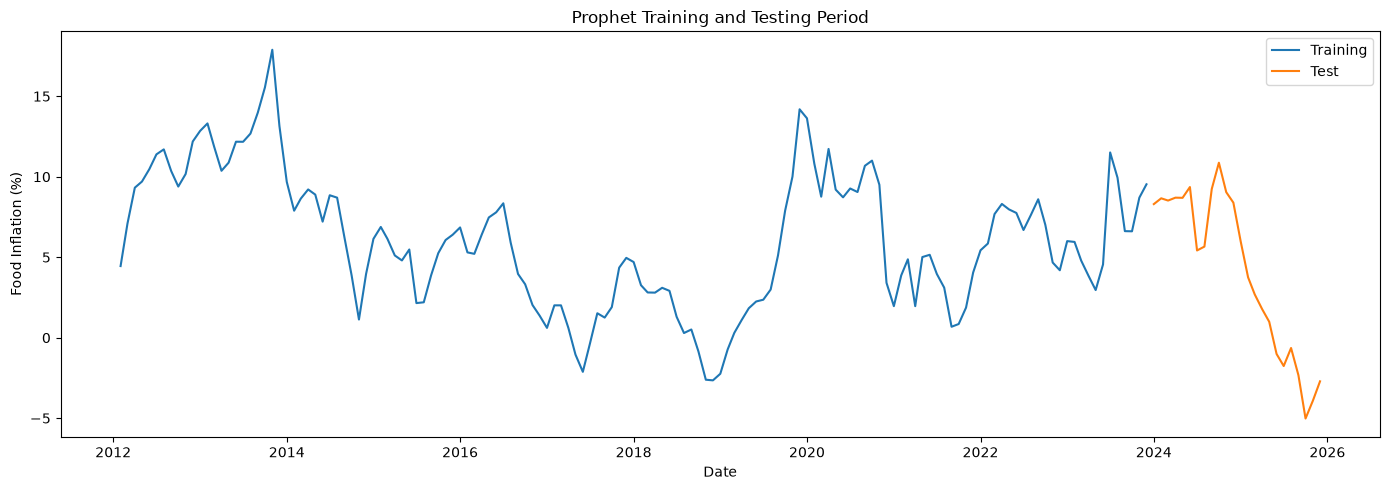

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(
    train["ds"],
    train["y"],
    label="Training"
)

plt.plot(
    test["ds"],
    test["y"],
    label="Test"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Prophet Training and Testing Period")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,

    seasonality_mode="additive",

    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,

    interval_width=0.95
)

In [9]:
model.add_regressor(
    "oni_lag1",
    mode="additive"
)

In [10]:
model.fit(train)

20:09:05 - cmdstanpy - INFO - Chain [1] start processing
20:09:07 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
future = test[
    ["ds", "oni_lag1"]
].copy()

display(future.head())

,ds,oni_lag1
143,2024-01-01,2.06
144,2024-02-01,1.92
145,2024-03-01,1.62
146,2024-04-01,1.26
147,2024-05-01,0.82


In [12]:
forecast = model.predict(future)

display(
    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].head(10)
)

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,3.494633,-4.252491,10.806892
1,2024-02-01,3.064483,-4.147633,10.610422
2,2024-03-01,3.371879,-4.783906,11.144923
3,2024-04-01,3.606333,-3.861826,11.239079
4,2024-05-01,3.774561,-3.806463,10.954323
5,2024-06-01,4.063045,-3.639336,11.826863
6,2024-07-01,4.647844,-3.322555,12.623334
7,2024-08-01,4.603095,-3.110940,11.875202
8,2024-09-01,4.381226,-2.715481,12.524052
9,2024-10-01,4.433706,-3.540889,12.843748


In [13]:
predictions = test[
    ["ds", "y"]
].copy()

predictions["predicted_food_inflation"] = (
    forecast["yhat"].values
)

predictions["lower_bound"] = (
    forecast["yhat_lower"].values
)

predictions["upper_bound"] = (
    forecast["yhat_upper"].values
)

predictions = predictions.rename(
    columns={
        "y": "actual_food_inflation"
    }
)

display(predictions.head())

,ds,actual_food_inflation,predicted_food_inflation,lower_bound,upper_bound
143,2024-01-01,8.30,3.494633,-4.252491,10.806892
144,2024-02-01,8.66,3.064483,-4.147633,10.610422
145,2024-03-01,8.52,3.371879,-4.783906,11.144923
146,2024-04-01,8.70,3.606333,-3.861826,11.239079
147,2024-05-01,8.69,3.774561,-3.806463,10.954323


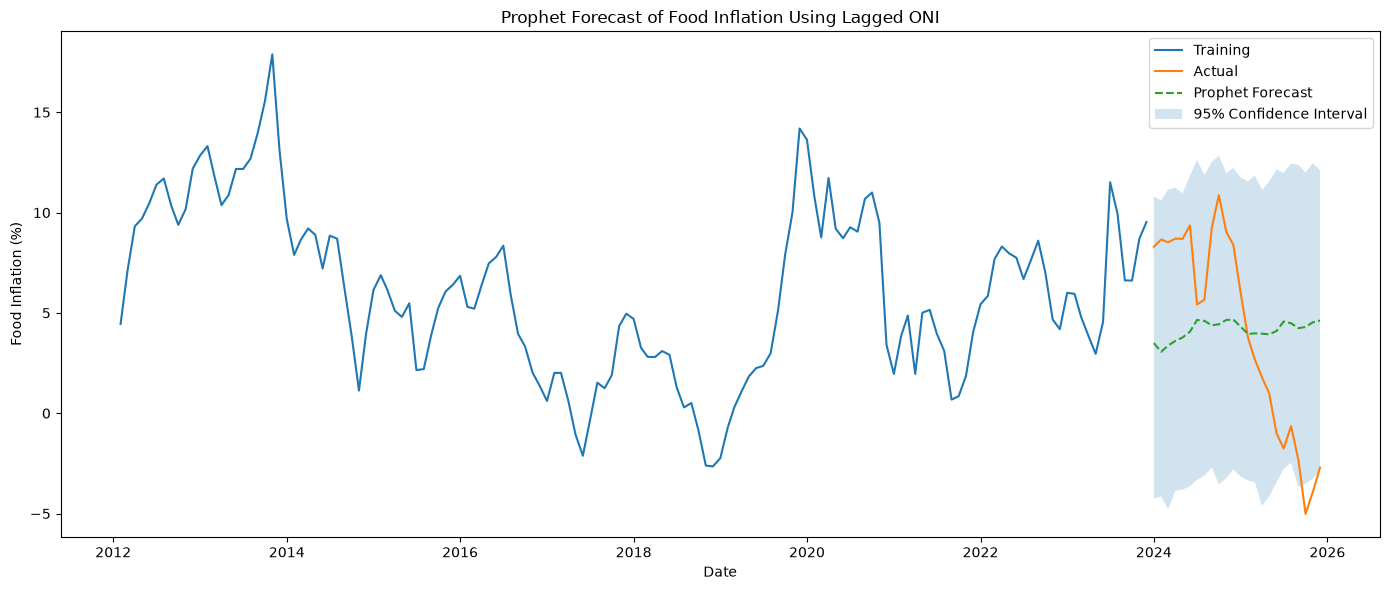

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    train["ds"],
    train["y"],
    label="Training"
)

plt.plot(
    test["ds"],
    test["y"],
    label="Actual"
)

plt.plot(
    predictions["ds"],
    predictions["predicted_food_inflation"],
    linestyle="--",
    label="Prophet Forecast"
)

plt.fill_between(
    predictions["ds"],
    predictions["lower_bound"],
    predictions["upper_bound"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Prophet Forecast of Food Inflation Using Lagged ONI")
plt.legend()

plt.tight_layout()
plt.show()

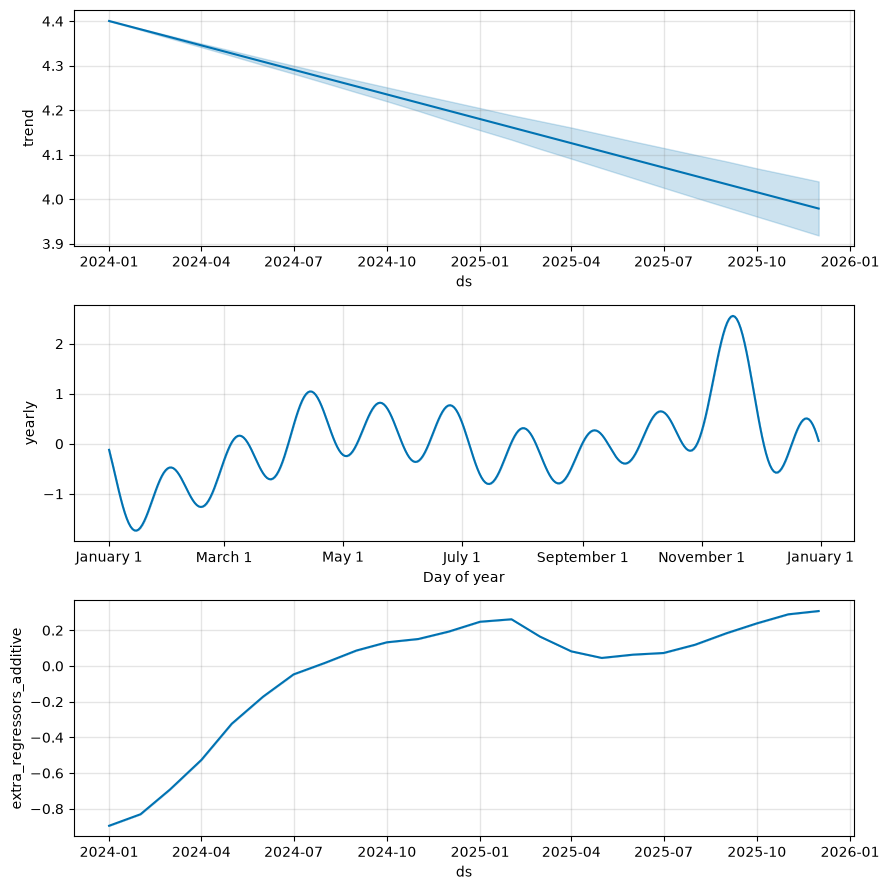

In [15]:
fig = model.plot_components(
    forecast
)

plt.show()

In [16]:
actual = predictions[
    "actual_food_inflation"
]

predicted = predictions[
    "predicted_food_inflation"
]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

smape = (
    100
    * np.mean(
        2 * np.abs(actual - predicted)
        / (
            np.abs(actual)
            + np.abs(predicted)
            + 1e-8
        )
    )
)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"sMAPE : {smape:.2f}%")

MAE   : 4.5247
RMSE  : 5.1001
sMAPE : 103.69%


In [17]:
predictions.to_csv(
    "../data/processed/prophet_predictions.csv",
    index=False
)

In [18]:
changepoint_values = [
    0.01,
    0.05,
    0.1,
    0.5
]

prophet_results = []

for cp in changepoint_values:

    model_test = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=cp,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    )

    model_test.add_regressor(
        "oni_lag1",
        mode="additive"
    )

    model_test.fit(train)

    forecast_test = model_test.predict(
        test[["ds", "oni_lag1"]]
    )

    y_pred = forecast_test["yhat"]

    mae_test = mean_absolute_error(
        test["y"],
        y_pred
    )

    rmse_test = np.sqrt(
        mean_squared_error(
            test["y"],
            y_pred
        )
    )

    smape_test = (
        100
        * np.mean(
            2 * np.abs(test["y"] - y_pred)
            / (
                np.abs(test["y"])
                + np.abs(y_pred)
                + 1e-8
            )
        )
    )

    prophet_results.append({
        "changepoint_prior_scale": cp,
        "MAE": mae_test,
        "RMSE": rmse_test,
        "sMAPE": smape_test
    })

prophet_results = pd.DataFrame(
    prophet_results
)

display(
    prophet_results.sort_values("RMSE")
)

20:09:13 - cmdstanpy - INFO - Chain [1] start processing
20:09:13 - cmdstanpy - INFO - Chain [1] done processing
20:09:14 - cmdstanpy - INFO - Chain [1] start processing
20:09:14 - cmdstanpy - INFO - Chain [1] done processing
20:09:15 - cmdstanpy - INFO - Chain [1] start processing
20:09:15 - cmdstanpy - INFO - Chain [1] done processing
20:09:15 - cmdstanpy - INFO - Chain [1] start processing
20:09:16 - cmdstanpy - INFO - Chain [1] done processing


,changepoint_prior_scale,MAE,RMSE,sMAPE
1,0.05,4.524748,5.100074,NaN
3,0.50,4.444149,5.540389,NaN
0,0.01,4.763420,5.953389,NaN
2,0.10,5.042723,6.519355,NaN
